In [20]:
import torch
print(f"GPUs Available: {torch.cuda.device_count()}")

GPUs Available: 1


In [21]:
!nvidia-smi

Sat May 30 03:46:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P0             25W /   70W |     207MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [22]:
%pip install dask-cuda

In [23]:
from dask_cuda import LocalCUDACluster
from dask.distributed import Client
# Inicializa el clúster usando todas las GPUs disponibles
cluster = LocalCUDACluster()
client = Client(cluster)
# Ver información del clúster (puertos, memoria, etc.)
print(client)

/usr/local/lib/python3.12/dist-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33843 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:37033
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:33843/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40281'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:35141 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:35141
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:35348
INFO:distributed.scheduler:Receive client connection: Client-301f88e8-5bda-11f1-85ea-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:35358


<Client: 'tcp://127.0.0.1:37033' processes=1 threads=1, memory=12.67 GiB>


### **Visualización del Dashboard de Dask**
Como estamos en Google Colab, el enlace local (127.0.0.1) no funcionará directamente. Se ejecuta la siguiente celda para obtener un enlace público que permita ver el estado de los workers y el balanceo de carga en tiempo real.

In [24]:
from google.colab import output
import dask.distributed

try:
    # Obtenemos el cliente activo
    client_active = dask.distributed.get_client()
    port = client_active.scheduler_info()['services']['dashboard']

    print(f"Mostrando Dashboard de Dask (Puerto {port}):")
    # Implementación para ver el Dashboard dentro del cuaderno
    output.serve_kernel_port_as_iframe(port, path='/status')

except Exception as e:
    print(f"Error al intentar mostrar el dashboard: {e}")
    print("Asegúrate de haber ejecutado la celda VuKrL5saQuSN para iniciar el clúster.")

Mostrando Dashboard de Dask (Puerto 33843):


<IPython.core.display.Javascript object>

## **Prueba basica inicializacion de cluster cada GPU como trabajador independiente**

In [25]:
from dask_cuda import LocalCUDACluster
from dask.distributed import Client
import cupy as cp # Librería para arreglos en GPU compatible con Dask
# 1. Crear un clúster donde dask-cuda detecta automáticamente las GPUs disponibles
cluster = LocalCUDACluster()

# 2. Conectar un cliente de Dask al clúster de GPUs
client = Client(cluster)
# 3. "Hola Mundo" funcional: Crear un arreglo en cada GPU y sumarlo
def hola_gpu():
# cp.cuda.Device().id permite saber qué GPU está respondiendo [15]
  return f"Hola desde la GPU {cp.cuda.Device().id}"
# Ejecutar la función en todos los trabajadores (GPUs)
resultados = client.run(hola_gpu)
print(resultados)

/usr/local/lib/python3.12/dist-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 42125 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:36673
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:42125/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:42463'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:35751 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:35751
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:34220
INFO:distributed.scheduler:Receive client connection: Client-3509c9aa-5bda-11f1-85ea-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:34236


{'tcp://127.0.0.1:35751': 'Hola desde la GPU 0'}


#**PARTE 1**
## **Ejercicio 1: Particionamiento de Datos (Fase 'P' de PCAM)**
### Este ejercicio ilustra cómo dividir un dominio de datos masivo en piezas individuales para exponer el paralelismo.


Validando salidas con diferentes tamaños de chunks y computando en paralelo:
  Procesando con chunks de tamaño: 100
    Estructura de chunks: ((100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100), (100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,

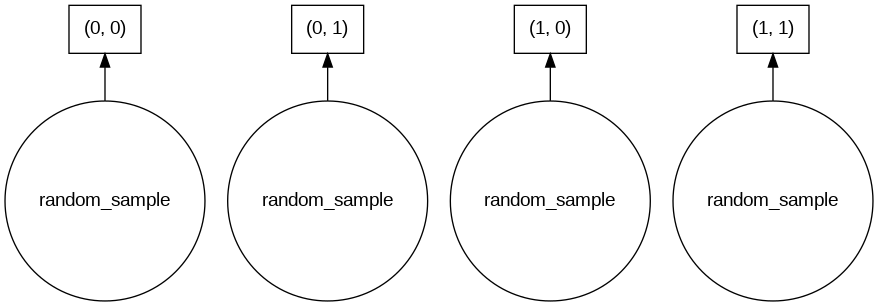

Suma calculada de forma diferida (sin compute): dask.array<sum-aggregate, shape=(), dtype=float64, chunksize=(), chunktype=numpy.ndarray>


In [26]:
import dask.array as da
import time
from IPython.display import Image, display

# Creamos un arreglo masivo de 10,000x10,000 (100 millones de elementos)
# El parámetro 'chunks' define el particionamiento (Partitioning)
# Prueba cambiando chunks=(1000, 1000) por chunks=(5000, 5000)
data = da.random.random((10000, 10000), chunks=(5000, 5000))

# Valide las salidas cambiando los valores de los chunks de 100 en 100 hasta 1000.
print("Validando salidas con diferentes tamaños de chunks y computando en paralelo:")
results_per_chunk_size = {}
for chunk_size in range(100, 1001, 100):
  rechunked_data = data.rechunk((chunk_size, chunk_size))
  print(f"  Procesando con chunks de tamaño: {chunk_size}")
  print(f"    Estructura de chunks: {rechunked_data.chunks}")

  start_time = time.time()
  # Perform a computation (e.g., sum) and trigger parallel execution with .compute()
  computed_sum = rechunked_data.sum().compute()
  end_time = time.time()

  duration = end_time - start_time
  results_per_chunk_size[chunk_size] = {"sum": computed_sum, "time_taken": duration}
  print(f"    Suma calculada: {computed_sum:.2f}, Tiempo de ejecución: {duration:.4f} segundos\n")

print("Resultados por tamaño de chunk:")
for chunk_size, res in results_per_chunk_size.items():
  print(f"  Chunk Size {chunk_size}: Sum={res['sum']:.2f}, Time={res['time_taken']:.4f}s")

# Visualizamos el grafo de tareas para ver las piezas individuales
# Esto representa la granularidad del algoritmo [3]
data.visualize(filename='mydask.png')
print("Grafo de tareas guardado como 'mydask.png'")
display(Image(filename='mydask.png'))

# Realizamos una operación (esto no ejecuta nada aún, es 'lazy')
resultado = data.sum()
print(f"Suma calculada de forma diferida (sin compute): {resultado}")

## **Ejercicio 2: Implementación del Patrón GSLP con Dask:**
### El patrón **GSLP (Globally Sequential, Locally Parallel)** implica que el programa principal es secuencial (el Host), pero lanza partes en paralelo (los Workers o Devices).

/usr/local/lib/python3.12/dist-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44875 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:41057
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:44875/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40097'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:44495'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:37485 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:37485
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:33862
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:38647 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:38647
IN

Primeros 10 resultados: [0, 1, 4, 9, 16, 25, 36, 49, 64, 81]


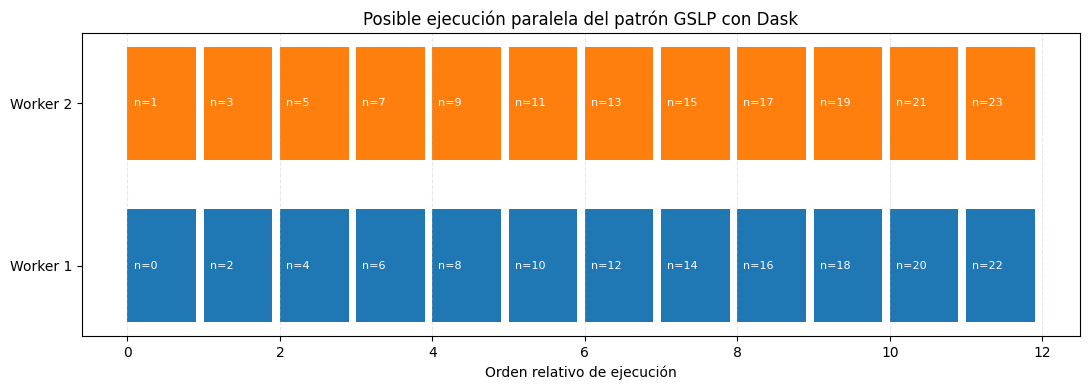

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from dask.distributed import Client

# Inicializamos el cliente (el "Host" que controla la secuencia)
client = Client()

# Definimos una función que será nuestro "kernel" localmente paralelo
def kernel_cuadrado(n):
    return n ** 2

# Lanzamos el cálculo de forma paralela
entradas = range(24)
futuros = client.map(kernel_cuadrado, entradas)
resultados = client.gather(futuros)
print(f"Primeros 10 resultados: {resultados[:10]}")

# Diagrama de una posible ejecución de hilos/workers
worker_ids = list(client.scheduler_info()["workers"].keys())
if not worker_ids:
    worker_ids = ["worker-1"]

asignaciones = defaultdict(list)
for indice, valor in enumerate(entradas):
    worker = worker_ids[indice % len(worker_ids)]
    asignaciones[worker].append(valor)

fig, ax = plt.subplots(figsize=(11, 4))
for fila, (worker, tareas_worker) in enumerate(asignaciones.items()):
    for posicion, valor in enumerate(tareas_worker):
        ax.broken_barh([(posicion, 0.9)], (fila - 0.35, 0.7), facecolors=f"C{fila % 10}")
        ax.text(posicion + 0.08, fila, f"n={valor}", va="center", ha="left", fontsize=8, color="white")

ax.set_yticks(range(len(asignaciones)))
ax.set_yticklabels([f"Worker {i + 1}" for i in range(len(asignaciones))])
ax.set_xlabel("Orden relativo de ejecución")
ax.set_title("Posible ejecución paralela del patrón GSLP con Dask")
ax.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## **Ejercicio 3: Balanceo de Carga (Fase 'Mapping' de PCAM)**
### El objetivo del **Mapeo** es lograr el **load balance**, asegurando que todos los nodos tengan aproximadamente la misma cantidad de trabajo.

Procesando tareas... observa el balanceo de carga en el Dashboard.


,tarea,tiempo_s,resultado
0,0,1.915143,Tarea 0 completada en 1.92s
1,1,2.122154,Tarea 1 completada en 2.12s
2,2,0.517901,Tarea 2 completada en 0.52s
3,3,1.161076,Tarea 3 completada en 1.16s
4,4,2.108300,Tarea 4 completada en 2.11s
5,5,0.775797,Tarea 5 completada en 0.78s
6,6,2.846527,Tarea 6 completada en 2.85s
7,7,2.759758,Tarea 7 completada en 2.76s
8,8,2.224221,Tarea 8 completada en 2.22s
9,9,1.196385,Tarea 9 completada en 1.20s


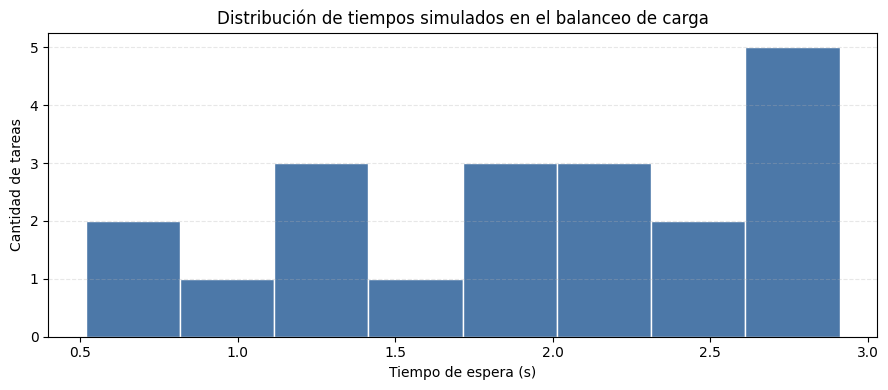

In [28]:
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from dask.distributed import Client
from IPython.display import display

# Función con tiempo de ejecución variable para simular desbalance
def tarea_desbalanceada(x):
    espera = random.uniform(0.5, 3.0)
    time.sleep(espera)
    return {"tarea": x, "tiempo_s": espera, "resultado": f"Tarea {x} completada en {espera:.2f}s"}

# Mapeamos 20 tareas a los trabajadores disponibles
# En el Dask Dashboard podrás ver cómo se distribuyen (Mapping)
tareas = range(20)
futuros_balanceo = client.map(tarea_desbalanceada, tareas)
print("Procesando tareas... observa el balanceo de carga en el Dashboard.")

resultados_balanceo = client.gather(futuros_balanceo)
resumen_balanceo = pd.DataFrame(resultados_balanceo)
display(resumen_balanceo.sort_values("tarea"))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(resumen_balanceo["tiempo_s"], bins=8, color="#4C78A8", edgecolor="white")
ax.set_title("Distribución de tiempos simulados en el balanceo de carga")
ax.set_xlabel("Tiempo de espera (s)")
ax.set_ylabel("Cantidad de tareas")
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# **Parte 2:**
## a) Los entorno de nube AWS poseen las familias AWS G7e P5,Trn2, P6, VT1 usadas para para trabajar con IA y GPUs, una vez analizadas realice una tabla con las siguientes características:
### Familia, Características Principales, Uso Cantidad de GPUs / Aceleradores, Cantidad de CPU (vCPUs), Cantidad de Memoria, Almacenamiento Mínimo (Local NVMe)

In [29]:
import pandas as pd
from IPython.display import display

# Evitar truncamiento de texto
pd.set_option('display.max_colwidth', None)

familias_aws = pd.DataFrame([
    {
        "Familia": "G7e*",
        "Características principales": "GPU orientada a inferencia y gráficos; referencia pública más cercana: G6e con NVIDIA L40S y Nitro",
        "Uso": "Inferencia de IA, spatial computing, visualización acelerada",
        "Cantidad de GPUs / aceleradores": "Hasta 8 GPUs L40S",
        "Cantidad de CPU (vCPUs)": "Hasta 192",
        "Cantidad de memoria": "Hasta 1.536 TB",
        "Almacenamiento mínimo (Local NVMe)": "Hasta 7.6 TB",
    },
    {
        "Familia": "P5",
        "Características principales": "Instancias GPU con NVIDIA H100/H200 para entrenamiento e HPC",
        "Uso": "Entrenamiento de LLMs, HPC, simulación científica",
        "Cantidad de GPUs / aceleradores": "Hasta 8 GPUs H100/H200",
        "Cantidad de CPU (vCPUs)": "Hasta 192",
        "Cantidad de memoria": "Hasta 2 TiB",
        "Almacenamiento mínimo (Local NVMe)": "8 x 3.84 TB NVMe SSD",
    },
    {
        "Familia": "Trn2",
        "Características principales": "Aceleradores AWS Trainium2 para IA generativa y entrenamiento a gran escala",
        "Uso": "Entrenamiento e inferencia de modelos fundacionales",
        "Cantidad de GPUs / aceleradores": "Hasta 16 chips Trainium2",
        "Cantidad de CPU (vCPUs)": "Hasta 192",
        "Cantidad de memoria": "Hasta 1.5 TB",
        "Almacenamiento mínimo (Local NVMe)": "4 x 1.92 TB NVMe SSD",
    },
    {
        "Familia": "P6",
        "Características principales": "Instancias Blackwell / Blackwell Ultra para IA de frontera",
        "Uso": "Entrenamiento e inferencia de modelos MoE y reasoning",
        "Cantidad de GPUs / aceleradores": "Hasta 8 GPUs Blackwell",
        "Cantidad de CPU (vCPUs)": "Hasta 192",
        "Cantidad de memoria": "Hasta 4 TiB",
        "Almacenamiento mínimo (Local NVMe)": "8 x 3.84 TB NVMe SSD",
    },
    {
        "Familia": "VT1",
        "Características principales": "Aceleración de transcodificación de video en tiempo real",
        "Uso": "Broadcast, videoconferencia y transcoding just-in-time",
        "Cantidad de GPUs / aceleradores": "Hasta 8 aceleradores Xilinx U30",
        "Cantidad de CPU (vCPUs)": "Hasta 96",
        "Cantidad de memoria": "Hasta 192 GB",
        "Almacenamiento mínimo (Local NVMe)": "No especificado / orientado a EBS",
    },
])

display(familias_aws.style.set_properties(**{'text-align': 'left'}))
print("Nota: G7e se deja como referencia equivalente pública de la familia gráfica G6e.")

,Familia,Características principales,Uso,Cantidad de GPUs / aceleradores,Cantidad de CPU (vCPUs),Cantidad de memoria,Almacenamiento mínimo (Local NVMe)
0,G7e*,GPU orientada a inferencia y gráficos; referencia pública más cercana: G6e con NVIDIA L40S y Nitro,"Inferencia de IA, spatial computing, visualización acelerada",Hasta 8 GPUs L40S,Hasta 192,Hasta 1.536 TB,Hasta 7.6 TB
1,P5,Instancias GPU con NVIDIA H100/H200 para entrenamiento e HPC,"Entrenamiento de LLMs, HPC, simulación científica",Hasta 8 GPUs H100/H200,Hasta 192,Hasta 2 TiB,8 x 3.84 TB NVMe SSD
2,Trn2,Aceleradores AWS Trainium2 para IA generativa y entrenamiento a gran escala,Entrenamiento e inferencia de modelos fundacionales,Hasta 16 chips Trainium2,Hasta 192,Hasta 1.5 TB,4 x 1.92 TB NVMe SSD
3,P6,Instancias Blackwell / Blackwell Ultra para IA de frontera,Entrenamiento e inferencia de modelos MoE y reasoning,Hasta 8 GPUs Blackwell,Hasta 192,Hasta 4 TiB,8 x 3.84 TB NVMe SSD
4,VT1,Aceleración de transcodificación de video en tiempo real,"Broadcast, videoconferencia y transcoding just-in-time",Hasta 8 aceleradores Xilinx U30,Hasta 96,Hasta 192 GB,No especificado / orientado a EBS


Nota: G7e se deja como referencia equivalente pública de la familia gráfica G6e.


## b) Con base en la tabla generada seleccione las mejores combinaciones de familias específicas para ejecutar los ejercicios propuestos (1,2 y 3 - Parte 1), tomar como mínimo los siguientes encabezados
### Ejercicio, Prioridad Arquitectónica, Familia AWS Recomendada, Motivo Técnico

In [30]:
import pandas as pd
from IPython.display import display

# Evitar truncamiento de texto
pd.set_option('display.max_colwidth', None)

recomendaciones = pd.DataFrame([
    {
        "Ejercicio": "1. Particionamiento de datos",
        "Prioridad arquitectónica": "Capacidad de memoria y ancho de banda",
        "Familia AWS recomendada": "P6",
        "Motivo técnico": "Es la opción más robusta para arreglos grandes y cargas de cómputo intensivo; su memoria local y escala de GPU ayudan a manejar particiones grandes sin degradar tanto el rendimiento.",
    },
    {
        "Ejercicio": "2. GSLP con Dask",
        "Prioridad arquitectónica": "Bajo costo por tarea y buena latencia de orquestación",
        "Familia AWS recomendada": "G7e",
        "Motivo técnico": "El ejemplo es ligero y depende más del scheduler que de cómputo crudo. Una GPU de gama intermedia permite ejecutar varios workers sin pagar la sobrecapacidad de P6 o P5.",
    },
    {
        "Ejercicio": "3. Balanceo de carga",
        "Prioridad arquitectónica": "Elasticidad y monitoreo de workers",
        "Familia AWS recomendada": "G7e",
        "Motivo técnico": "La carga está dominada por tareas heterogéneas y esperas variables; conviene una familia costo-eficiente para observar el reparto de trabajo sin sobredimensionar infraestructura.",
    },
])

display(recomendaciones.style.set_properties(**{'text-align': 'left'}))
print("P6 para el ejercicio más pesado de datos; G7e para las demos de Dask por costo/eficiencia.")

,Ejercicio,Prioridad arquitectónica,Familia AWS recomendada,Motivo técnico
0,1. Particionamiento de datos,Capacidad de memoria y ancho de banda,P6,Es la opción más robusta para arreglos grandes y cargas de cómputo intensivo; su memoria local y escala de GPU ayudan a manejar particiones grandes sin degradar tanto el rendimiento.
1,2. GSLP con Dask,Bajo costo por tarea y buena latencia de orquestación,G7e,El ejemplo es ligero y depende más del scheduler que de cómputo crudo. Una GPU de gama intermedia permite ejecutar varios workers sin pagar la sobrecapacidad de P6 o P5.
2,3. Balanceo de carga,Elasticidad y monitoreo de workers,G7e,La carga está dominada por tareas heterogéneas y esperas variables; conviene una familia costo-eficiente para observar el reparto de trabajo sin sobredimensionar infraestructura.


P6 para el ejercicio más pesado de datos; G7e para las demos de Dask por costo/eficiencia.


## c) Ahora requerimos calcular el costo mensual y anual de estos servicios (Ejercicios 1,2 y 3) que variables son importantes respecto a los parámetros de la calculadora de AWS en infraestructura y que parámetros son importantes en modo IA (Usar la calculadora de AWS https://calculator.aws/#/)

In [31]:
import pandas as pd
from IPython.display import display

# Evitar truncamiento de texto
pd.set_option('display.max_colwidth', None)

variables_costo = pd.DataFrame([
    {
        "Modo": "Infraestructura",
        "Variables importantes": "tipo de instancia, número de instancias, región, horas/mes, compra On-Demand/Spot/Savings Plans, EBS, snapshots, transferencias de datos",
        "Parámetros que se ajustan": "tamaño de nodo, escalado horizontal, almacenamiento, red entre zonas, reserva o pago por demanda",
        "Fórmula práctica": "costo mensual = tarifa_hora × horas_uso × cantidad_instancias + almacenamiento + red + I/O",
    },
    {
        "Modo": "IA / GPU",
        "Variables importantes": "número de GPUs o aceleradores, memoria por GPU, VRAM total, entrenamiento vs inferencia, tiempo de cómputo por experimento, EFA / UltraCluster, checkpoints",
        "Parámetros que se ajustan": "model size, batch size, precision (FP16/BF16/FP8), distribución del entrenamiento, almacenamiento temporal y ancho de banda",
        "Fórmula práctica": "costo mensual = (tarifa_hora GPU × horas_entrenamiento) + almacenamiento de datasets + checkpoints + red",
    },
])

display(variables_costo.style.set_properties(**{'text-align': 'left'}))

resumen_costos = pd.DataFrame([
    {"Ejercicio": "1", "Mensual": "tarifa_hora_1 × horas_1", "Anual": "12 × mensual"},
    {"Ejercicio": "2", "Mensual": "tarifa_hora_2 × horas_2", "Anual": "12 × mensual"},
    {"Ejercicio": "3", "Mensual": "tarifa_hora_3 × horas_3", "Anual": "12 × mensual"},
])

display(resumen_costos.style.set_properties(**{'text-align': 'left'}))
print("Use AWS Calculator para reemplazar los parámetros por valores reales.")

,Modo,Variables importantes,Parámetros que se ajustan,Fórmula práctica
0,Infraestructura,"tipo de instancia, número de instancias, región, horas/mes, compra On-Demand/Spot/Savings Plans, EBS, snapshots, transferencias de datos","tamaño de nodo, escalado horizontal, almacenamiento, red entre zonas, reserva o pago por demanda",costo mensual = tarifa_hora × horas_uso × cantidad_instancias + almacenamiento + red + I/O
1,IA / GPU,"número de GPUs o aceleradores, memoria por GPU, VRAM total, entrenamiento vs inferencia, tiempo de cómputo por experimento, EFA / UltraCluster, checkpoints","model size, batch size, precision (FP16/BF16/FP8), distribución del entrenamiento, almacenamiento temporal y ancho de banda",costo mensual = (tarifa_hora GPU × horas_entrenamiento) + almacenamiento de datasets + checkpoints + red


,Ejercicio,Mensual,Anual
0,1,tarifa_hora_1 × horas_1,12 × mensual
1,2,tarifa_hora_2 × horas_2,12 × mensual
2,3,tarifa_hora_3 × horas_3,12 × mensual


Use AWS Calculator para reemplazar los parámetros por valores reales.


## d) Realice una tabla con el detalle de memoria RAM requerida por cada una de las familia seleccionadas en el punto anterior y analice las ventajas y desventajas de la selección realizada.

In [32]:
import pandas as pd
from IPython.display import display

# Configuramos pandas para que no trunque el contenido de las celdas
pd.set_option('display.max_colwidth', None)

memoria_analisis = pd.DataFrame([
    {
        "Familia": "G7e*",
        "RAM requerida": "Hasta 1.536 TB",
        "Ventajas": "Equilibrio entre costo y memoria para inferencia y visualización; suficiente para demos de Dask y particionado moderado.",
        "Desventajas": "No está pensada para los modelos más grandes ni para entrenamiento extremo de frontera.",
    },
    {
        "Familia": "P6",
        "RAM requerida": "Hasta 4 TiB",
        "Ventajas": "Máxima holgura para datos masivos, entrenamiento distribuido y cargas de IA de frontera.",
        "Desventajas": "Costo muy alto; para ejercicios sencillos puede sobredimensionar la solución.",
    },
    {
        "Familia": "VT1",
        "RAM requerida": "Hasta 192 GB",
        "Ventajas": "Muy eficiente para su caso de uso específico: transcodificación de video en tiempo real.",
        "Desventajas": "No es la mejor opción para ejercicios de IA general o entrenamiento GPU tradicional.",
    },
    {
        "Familia": "Trn2",
        "RAM requerida": "Hasta 1.5 TB",
        "Ventajas": "Excelente relación precio/rendimiento para entrenamiento e inferencia con Trainium2 y gran memoria total.",
        "Desventajas": "Requiere adaptación al ecosistema Neuron; no es una GPU CUDA clásica.",
    },
])

# Aplicamos estilo para alinear a la izquierda y facilitar la lectura del texto largo
display(memoria_analisis.style.set_properties(**{'text-align': 'left'}))
print("\nConclusión: para la práctica, P6 domina el ejercicio de datos grandes, mientras que G7e cubre de forma más eficiente las demostraciones de Dask.")

,Familia,RAM requerida,Ventajas,Desventajas
0,G7e*,Hasta 1.536 TB,Equilibrio entre costo y memoria para inferencia y visualización; suficiente para demos de Dask y particionado moderado.,No está pensada para los modelos más grandes ni para entrenamiento extremo de frontera.
1,P6,Hasta 4 TiB,"Máxima holgura para datos masivos, entrenamiento distribuido y cargas de IA de frontera.",Costo muy alto; para ejercicios sencillos puede sobredimensionar la solución.
2,VT1,Hasta 192 GB,Muy eficiente para su caso de uso específico: transcodificación de video en tiempo real.,No es la mejor opción para ejercicios de IA general o entrenamiento GPU tradicional.
3,Trn2,Hasta 1.5 TB,Excelente relación precio/rendimiento para entrenamiento e inferencia con Trainium2 y gran memoria total.,Requiere adaptación al ecosistema Neuron; no es una GPU CUDA clásica.



Conclusión: para la práctica, P6 domina el ejercicio de datos grandes, mientras que G7e cubre de forma más eficiente las demostraciones de Dask.
